<a href="https://colab.research.google.com/github/hawa1983/SD/blob/main/safety_and_support.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Data Preparation & Cleaning**

**Purpose:** Load data, standardize fields, and prepare for analysis

In [5]:
import pandas as pd

# Load data
df = pd.read_excel("workorders.xlsx")

# Clean column names
df.columns = [str(col).strip() for col in df.columns]

# Parse dates
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year

# Keep relevant fields
df_clean = df[["Year", "Facility", "Location", "Type", "Request"]].copy()
df_clean = df_clean.dropna(subset=["Request"])
display(df_clean)

,Year,Facility,Location,Type,Request
0,2025,Janovic Paint,55 Thompson Street,pick up,paint for Roseanne office
1,2025,Stillwell Avenue,Crew facility,delivery,delivered cabinet for Vega
2,2025,2717 Jackson Avenue,Roseanne Cummings office,paint,started painting office
3,2025,Sub Division C,130 Livingston Street,Fastenal,door stop
4,2025,Concourse Yard,Tower,repair,b/o door lock
...,...,...,...,...,...
13189,2026,207 Street Yard,Trailer,repair,"sinking platform, trip hazard"
13190,2026,Concourse Yard,Tower,repair,install temporary lighting
13191,2026,Concourse Yard,Tower,repair,paint door
13192,2026,Parsons Archer,Men,repair,toilet overflowing


## **2. Classify Defects by Component**
**Purpose:** Translate raw request text into meaningful system categories

In [6]:
def classify_component(text):
    t = str(text).lower()

    if any(x in t for x in ["door","lock","closer","handle","hinge","knob","gate"]):
        return "Door"
    if any(x in t for x in ["toilet","stall","bathroom","restroom","sink"]):
        return "Restroom"
    if any(x in t for x in ["light","lighting","bulb","fixture"]):
        return "Lighting"
    if any(x in t for x in ["heat","hvac","ac","vent","fan"]):
        return "HVAC"
    if any(x in t for x in ["water","leak","plumb","clog","drain"]):
        return "Plumbing/Water"
    if any(x in t for x in ["tile","cement","floor","wall","ceiling","roof"]):
        return "Structure"
    return "Other"

df_clean["Component"] = df_clean["Request"].apply(classify_component)

## **3. Identify Facility-Related Defects**
**Purpose:** Filter out non-facility issues (focus only on infrastructure defects)

In [8]:
facility_keywords = [
    "b/o","broken","defect","not working","malfunction","repair",
    "door","lock","handle","closer","hinge",
    "light","hvac","heat","ac",
    "water","leak","plumb","clog","drain",
    "roof","window","tile","cement","floor","wall","ceiling",
    "toilet","bathroom","restroom","sink"
]

pattern = "|".join(facility_keywords)

df_fac = df_clean[
    df_clean["Request"].astype(str).str.lower().str.contains(pattern, na=False)
].copy()

display(df_fac.head())

,Year,Facility,Location,Type,Request,Component
3,2025,Sub Division C,130 Livingston Street,Fastenal,door stop,Door
4,2025,Concourse Yard,Tower,repair,b/o door lock,Door
5,2025,Main Street,Men Restroom - Mezzanine Level,repair,toilet not flushing adequately,Restroom
6,2025,Parsons Archer,Men Locker Room,repair,b/o doorstop,Door
7,2025,Metropolitan Avenue,Men Restroom,replace,b/o toilet seat,Restroom


## **4. Executive Summary Metrics**
**Purpose:** Provide high-level KPIs for leadership

In [9]:
top_facility = df_fac.groupby("Facility").size().sort_values(ascending=False)
top_component = df_fac.groupby("Component").size().sort_values(ascending=False)

executive_summary = pd.DataFrame({
    "Metric": [
        "Total facility-related defects",
        "Number of facilities impacted",
        "Top facility",
        "Top facility defect count",
        "Top component",
        "Top component defect count"
    ],
    "Value": [
        len(df_fac),
        df_fac["Facility"].nunique(),
        top_facility.index[0],
        top_facility.iloc[0],
        top_component.index[0],
        top_component.iloc[0]
    ]
})

executive_summary

,Metric,Value
0,Total facility-related defects,9516
1,Number of facilities impacted,546
2,Top facility,Stillwell Avenue
3,Top facility defect count,240
4,Top component,Door
5,Top component defect count,2465


## **5. Facilities with Highest Defect Volume**
**Purpose:** Identify where problems are most concentrated

In [10]:
top_10_facilities = (
    df_fac.groupby("Facility")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Defect Count", ascending=False)
    .head(10)
)

top_10_facilities

,Facility,Defect Count
507,Stillwell Avenue,240
104,241 Street,221
243,Canarsie Rockaway Parkway,217
414,Main Street,188
461,Pelham Bay Park,180
542,Woodlawn,150
524,Utica Avenue,150
404,Lefferts Boulevard,148
85,207 Street,143
44,148 Street,142


## 6. **Defects by System (Component Analysis)**
**Purpose:** Understand what types of systems are failing most

In [11]:
component_summary = (
    df_fac.groupby("Component")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Defect Count", ascending=False)
)

component_summary

,Component,Defect Count
0,Door,2465
5,Restroom,2054
2,Lighting,1480
1,HVAC,1098
4,Plumbing/Water,1054
3,Other,820
6,Structure,545


## **7. Defect Trend Over Time**
**Purpose:** Identify whether issues are increasing or decreasing

In [12]:
year_summary = (
    df_fac.groupby("Year")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Year")
)

year_summary

,Year,Defect Count
0,2020,1216
1,2021,1385
2,2022,1301
3,2023,1432
4,2024,1755
5,2025,1916
6,2026,511


## **8. Breakdown of Top Facilities by System**
**Purpose:** Show what types of issues are happening at major facilities

In [13]:
top5 = top_10_facilities["Facility"].head(5)

facility_component = pd.pivot_table(
    df_fac[df_fac["Facility"].isin(top5)],
    index="Facility",
    columns="Component",
    values="Request",
    aggfunc="count",
    fill_value=0
)

facility_component

Component,Door,HVAC,Lighting,Other,Plumbing/Water,Restroom,Structure
Facility,,,,,,,
241 Street,79,27,12,24,18,48,13
Canarsie Rockaway Parkway,59,19,25,24,27,43,20
Main Street,45,29,19,10,22,55,8
Pelham Bay Park,43,23,19,20,16,36,23
Stillwell Avenue,61,31,27,27,18,65,11


## **9. Recurring Problem Locations (Hotspots)**
**Purpose:** Identify specific areas within facilities driving defects

In [14]:
location_hotspots = (
    df_fac.groupby(["Facility","Location"])
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Defect Count", ascending=False)
    .head(15)
)

location_hotspots

,Facility,Location,Defect Count
4647,Various Locations,Various Locations,100
0,Various Locations,Various Locations,35
4596,Utica Avenue,Tower,32
847,241 Street,Crew room,31
1255,59 Street,Tower,31
2237,Dekalb Avenue,Tower,30
3392,Main Street,Crew room,28
3951,Pelham Bay Park,Crew room,27
1787,Canarsie Rockaway Parkway,Men restroom,26
3970,Pelham Bay Park,Men restroom,25


## **10. Most Common Defect Types**
**Purpose:** Show the exact issues occurring most frequently

In [15]:
top_requests = (
    df_fac.groupby(["Component","Request"])
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Defect Count", ascending=False)
    .head(20)
)

top_requests

,Component,Request,Defect Count
4231,Restroom,clogged sink,152
3236,Other,eed repair,143
2630,Lighting,eed is dirty with graffitti and poor lighting,112
4257,Restroom,clogged toilet,108
2743,Lighting,light bulbs out,105
2636,Lighting,eed is dirty with poor lighting,103
3534,Plumbing/Water,ceiling leak,87
2890,Lighting,lights out,80
3761,Plumbing/Water,no hot water,75
4936,Restroom,toilet not flushing,60


## **11. Facilities with Highest Defect Volume (Bar Chart)**
**Purpose:** Highlight which facilities contribute most to overall defects

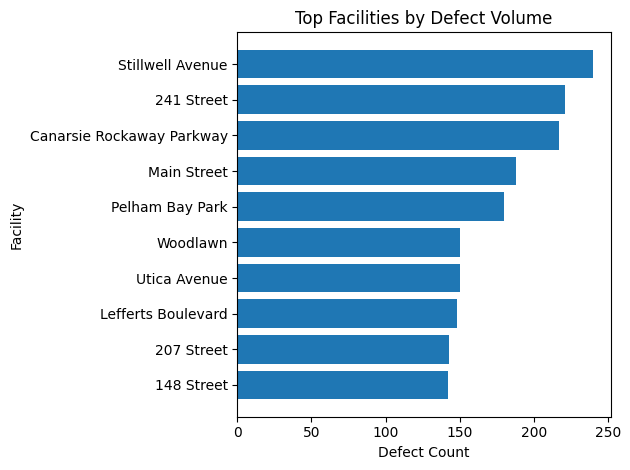

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_10_facilities["Facility"], top_10_facilities["Defect Count"])
plt.title("Top Facilities by Defect Volume")
plt.xlabel("Defect Count")
plt.ylabel("Facility")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **12. Defect Distribution by System (Pie Chart)**
**Purpose:** Show which types of components (systems) are failing most

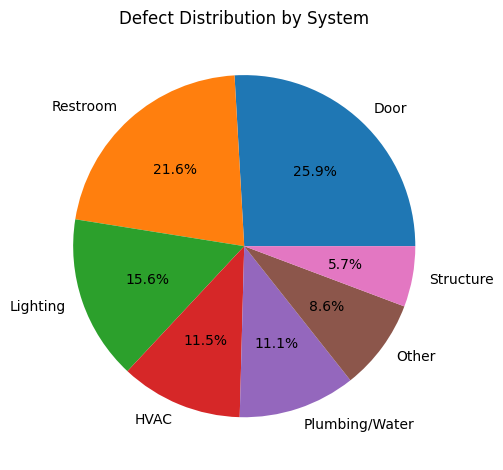

In [18]:
plt.figure()
plt.pie(
    component_summary["Defect Count"],
    labels=component_summary["Component"],
    autopct="%1.1f%%"
)
plt.title("Defect Distribution by System")
plt.tight_layout()
plt.show()

## **13. Defect Trend Over Time (Line Chart)**
**Purpose:** Identify whether defect volume is increasing, decreasing, or stable over time

In [28]:
import pandas as pd

# Create YearMonth from Date
df_fac["YearMonth"] = df_fac["Date"].dt.to_period("M").dt.to_timestamp()

# Aggregate defects by month
monthly_summary = (
    df_fac.groupby("YearMonth")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("YearMonth")
)

# Add Year and Month
monthly_summary["Year"] = monthly_summary["YearMonth"].dt.year
monthly_summary["Month"] = monthly_summary["YearMonth"].dt.month

# Split data
monthly_pre_2026 = monthly_summary[monthly_summary["Year"] < 2026].copy()
monthly_2026 = monthly_summary[monthly_summary["Year"] == 2026].copy()

# Exclude the last available month in 2026
if not monthly_2026.empty:
    last_month_2026 = monthly_2026["YearMonth"].max()
    monthly_2026 = monthly_2026[monthly_2026["YearMonth"] < last_month_2026].copy()

display(monthly_pre_2026.tail())
display(monthly_2026)



,YearMonth,Defect Count,Year,Month
67,2025-08-01,111,2025,8
68,2025-09-01,154,2025,9
69,2025-10-01,123,2025,10
70,2025-11-01,94,2025,11
71,2025-12-01,130,2025,12


,YearMonth,Defect Count,Year,Month
72,2026-01-01,189,2026,1
73,2026-02-01,152,2026,2
74,2026-03-01,159,2026,3


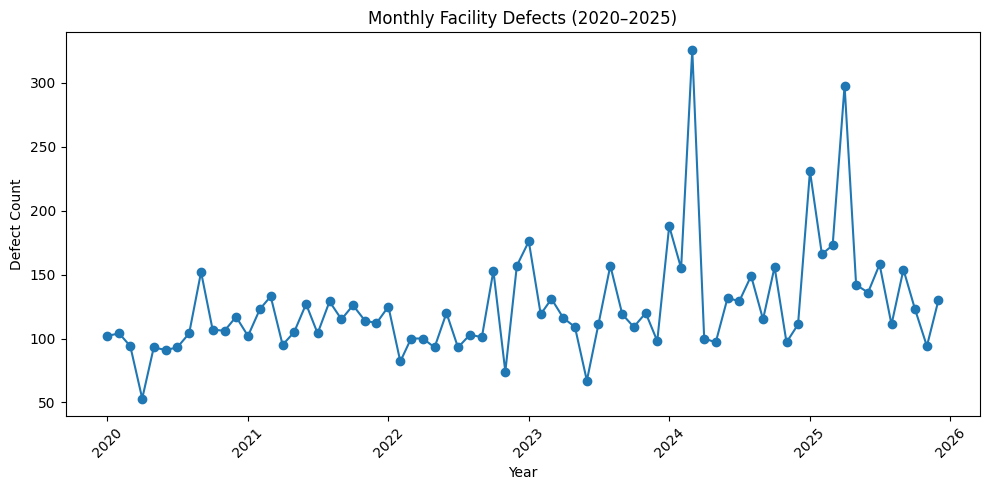

In [29]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(10, 5))
plt.plot(monthly_pre_2026["YearMonth"], monthly_pre_2026["Defect Count"], marker="o")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Monthly Facility Defects (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Defect Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

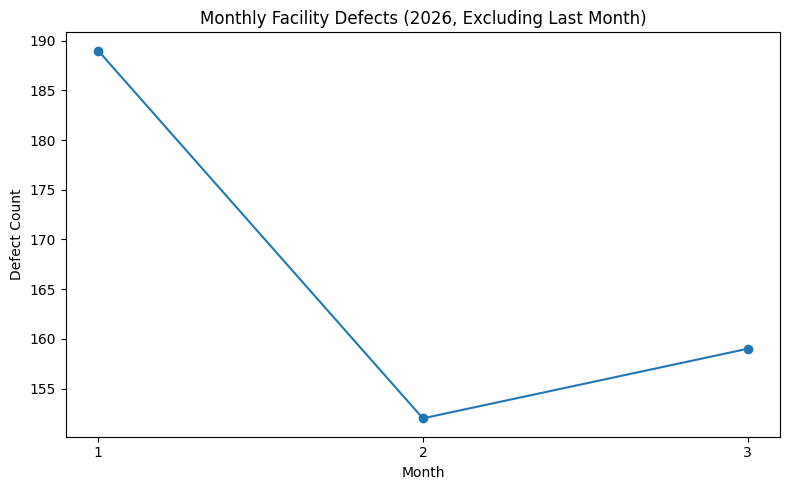

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(monthly_2026["Month"], monthly_2026["Defect Count"], marker="o")

plt.title("Monthly Facility Defects (2026, Excluding Last Month)")
plt.xlabel("Month")
plt.ylabel("Defect Count")
plt.xticks(monthly_2026["Month"])
plt.tight_layout()
plt.show()

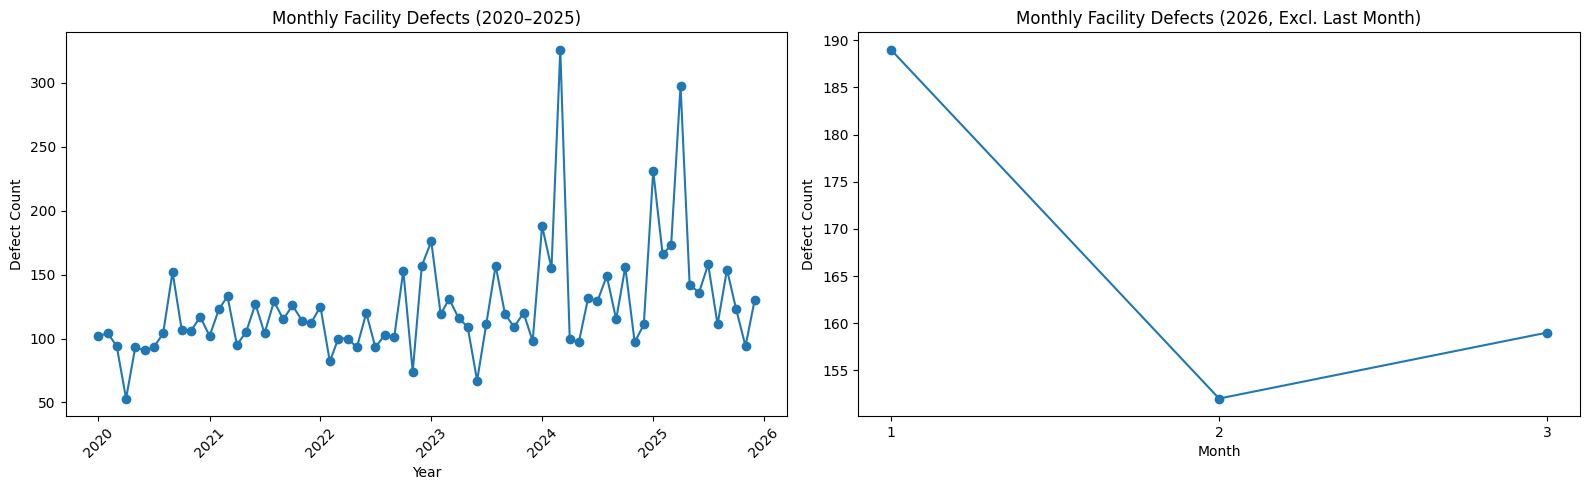

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: 2020-2025
axes[0].plot(monthly_pre_2026["YearMonth"], monthly_pre_2026["Defect Count"], marker="o")
axes[0].set_title("Monthly Facility Defects (2020–2025)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Defect Count")
axes[0].tick_params(axis="x", rotation=45)

axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Right: 2026
axes[1].plot(monthly_2026["Month"], monthly_2026["Defect Count"], marker="o")
axes[1].set_title("Monthly Facility Defects (2026, Excl. Last Month)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Defect Count")
axes[1].set_xticks(monthly_2026["Month"])

plt.tight_layout()
plt.show()

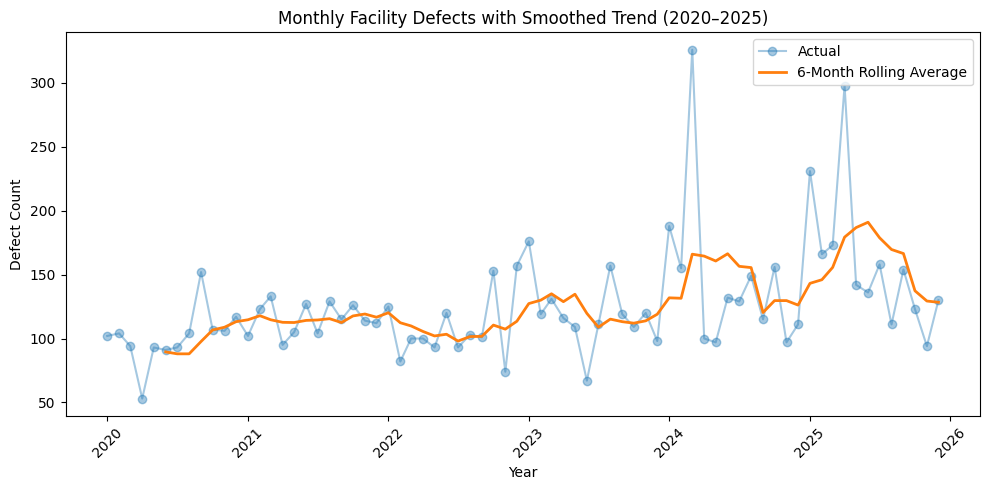

In [32]:
monthly_pre_2026["Rolling Avg (6M)"] = monthly_pre_2026["Defect Count"].rolling(6).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_pre_2026["YearMonth"], monthly_pre_2026["Defect Count"], alpha=0.4, marker="o", label="Actual")
plt.plot(monthly_pre_2026["YearMonth"], monthly_pre_2026["Rolling Avg (6M)"], linewidth=2, label="6-Month Rolling Average")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.title("Monthly Facility Defects with Smoothed Trend (2020–2025)")
plt.xlabel("Year")
plt.ylabel("Defect Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

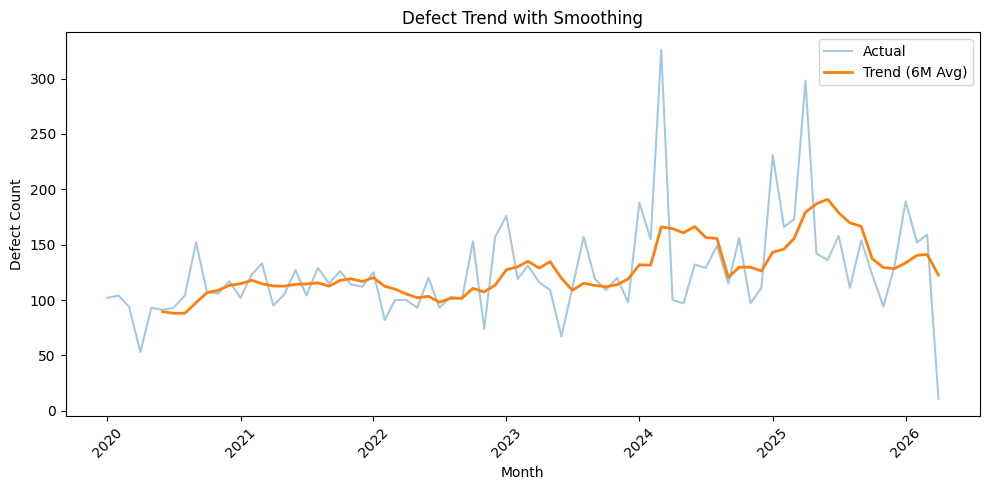

In [33]:
# Create YearMonth from Date
df_fac["YearMonth"] = df_fac["Date"].dt.to_period("M").dt.to_timestamp()

# Aggregate defects by month
monthly_summary = (
    df_fac.groupby("YearMonth")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("YearMonth")
)

# Convert to time series
# monthly_ts = monthly_summary.set_index("YearMonth")["Defect Count"]

# monthly_summary.head()

# import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 5))
# plt.plot(monthly_ts.index, monthly_ts.values, marker="o")

# plt.title("Monthly Facility Defects - Observed Time Series")
# plt.xlabel("Month")
# plt.ylabel("Defect Count")

# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()



monthly_summary["Rolling Avg (6M)"] = monthly_summary["Defect Count"].rolling(6).mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_summary["YearMonth"], monthly_summary["Defect Count"], alpha=0.4, label="Actual")
plt.plot(monthly_summary["YearMonth"], monthly_summary["Rolling Avg (6M)"], linewidth=2, label="Trend (6M Avg)")

plt.title("Defect Trend with Smoothing")
plt.xlabel("Month")
plt.ylabel("Defect Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

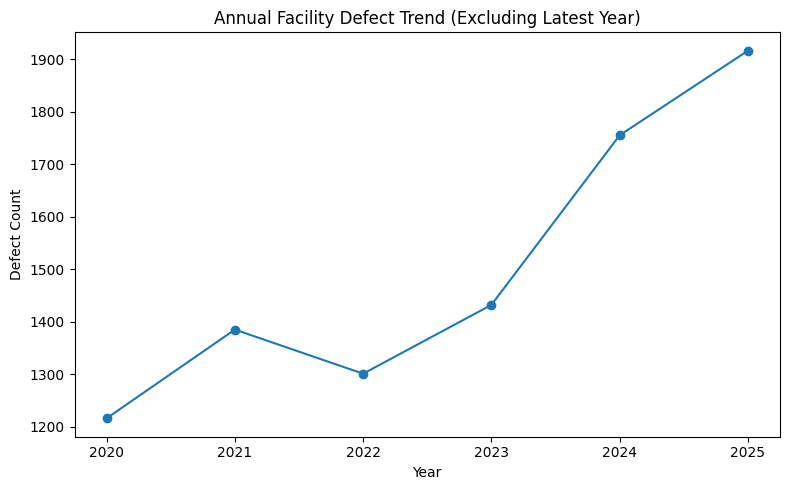

In [34]:
# Aggregate defects by year
annual_summary = (
    df_fac.groupby("Year")
    .size()
    .reset_index(name="Defect Count")
    .sort_values("Year")
)

# Exclude the last year (e.g., 2026)
last_year = annual_summary["Year"].max()
annual_filtered = annual_summary[annual_summary["Year"] < last_year].copy()

annual_filtered

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(annual_filtered["Year"], annual_filtered["Defect Count"], marker="o")

plt.title("Annual Facility Defect Trend (Excluding Latest Year)")
plt.xlabel("Year")
plt.ylabel("Defect Count")

plt.xticks(annual_filtered["Year"])
plt.tight_layout()
plt.show()

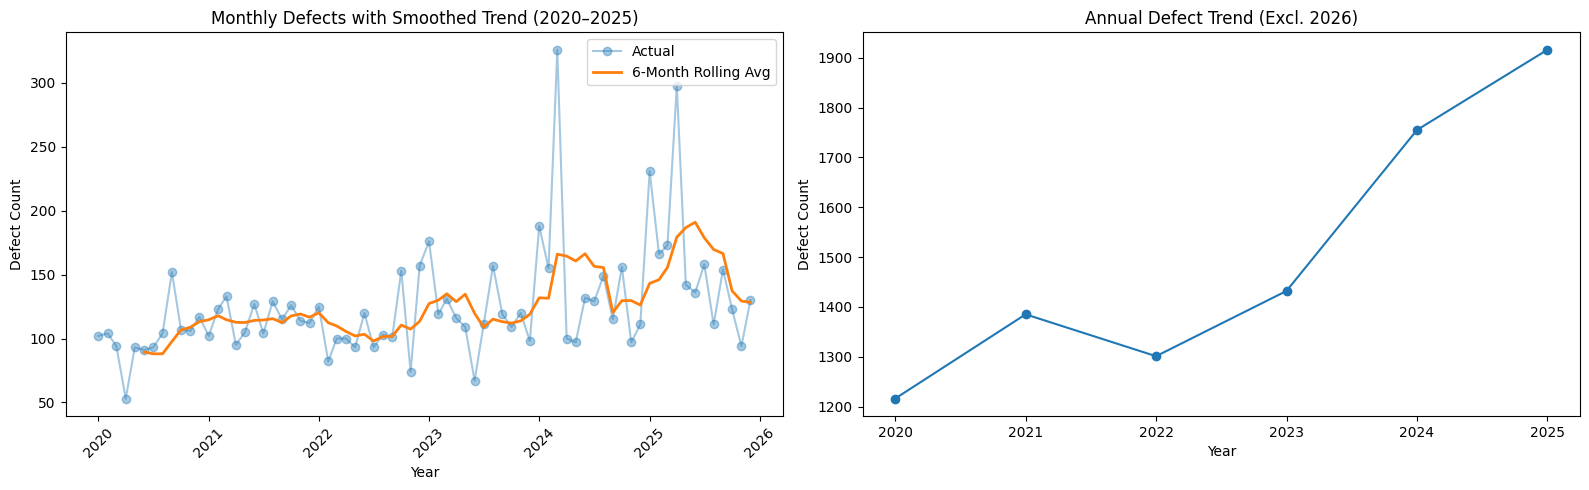

In [35]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure rolling average exists
monthly_pre_2026["Rolling Avg (6M)"] = monthly_pre_2026["Defect Count"].rolling(6).mean()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# =========================
# Left: Monthly Trend
# =========================
axes[0].plot(
    monthly_pre_2026["YearMonth"],
    monthly_pre_2026["Defect Count"],
    alpha=0.4,
    marker="o",
    label="Actual"
)

axes[0].plot(
    monthly_pre_2026["YearMonth"],
    monthly_pre_2026["Rolling Avg (6M)"],
    linewidth=2,
    label="6-Month Rolling Avg"
)

axes[0].set_title("Monthly Defects with Smoothed Trend (2020–2025)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Defect Count")

axes[0].xaxis.set_major_locator(mdates.YearLocator())
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# =========================
# Right: Annual Trend
# =========================
axes[1].plot(
    annual_filtered["Year"],
    annual_filtered["Defect Count"],
    marker="o"
)

axes[1].set_title("Annual Defect Trend (Excl. 2026)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Defect Count")

axes[1].set_xticks(annual_filtered["Year"])

# =========================
# Layout
# =========================
plt.tight_layout()
plt.show()

## **14. System Breakdown at Top Facilities (Stacked Bar Chart)**
**Purpose:** Compare which systems are driving defects at each high-volume facility

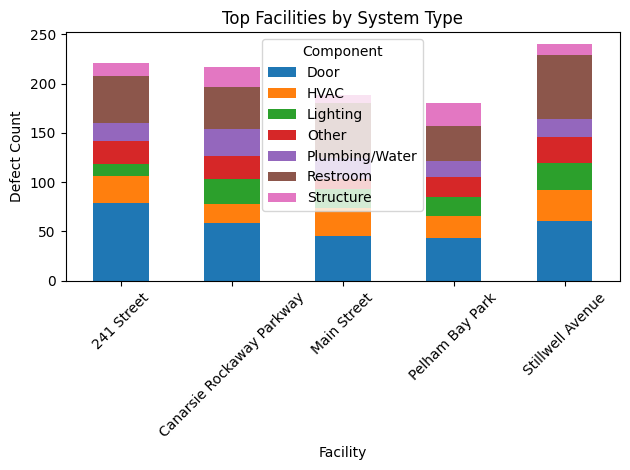

In [20]:
facility_component.plot(kind="bar", stacked=True)
plt.title("Top Facilities by System Type")
plt.xlabel("Facility")
plt.ylabel("Defect Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()